In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
FOOD_CAT = 101 + 80
IMG_SIZE = (224, 224)
IMG_SHAPE = (IMG_SIZE) + (3,)
BATCH_SIZE = 32

In [4]:
train_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Train/Train",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 57838 files belonging to 181 classes.


In [5]:
test_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Test/Test",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 14493 files belonging to 181 classes.


In [6]:
tf.data.experimental.cardinality(train_dir).numpy()

1808

In [7]:
tf.data.experimental.cardinality(test_dir).numpy()

453

In [8]:
class_names = train_dir.class_names

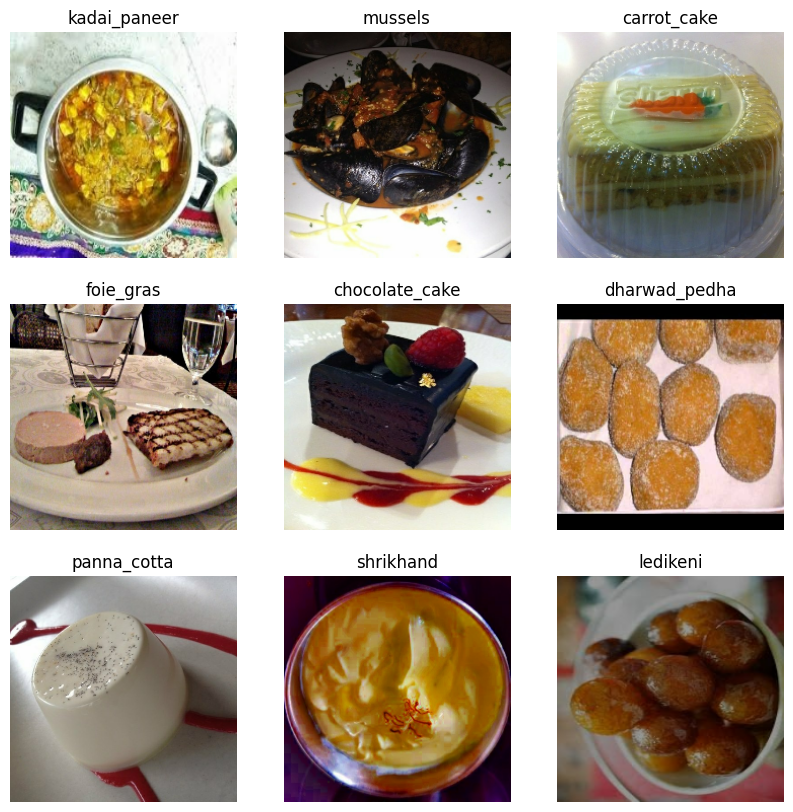

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_dir.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dir = train_dir.prefetch(buffer_size=AUTOTUNE)
test_dir = test_dir.prefetch(buffer_size=AUTOTUNE)

In [103]:
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)

In [53]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)

In [11]:
base_model =  ResNet50(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [13]:
base_model.trainable = False

In [14]:
for image_batch, label_batch in train_dir.take(1):
    feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 2048)


In [15]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 2048)


In [16]:
prediction_layer = Dense(FOOD_CAT, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 181)


In [17]:
x = base_model.input
x = base_model(x, training= False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.4)(x)
predictions = prediction_layer(x)

In [18]:
model = Model(inputs=base_model.input, outputs= predictions)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 181)                 │         370,869 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,958,581 (91.39 MB)

 Trainable params: 370,869 (1.41 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

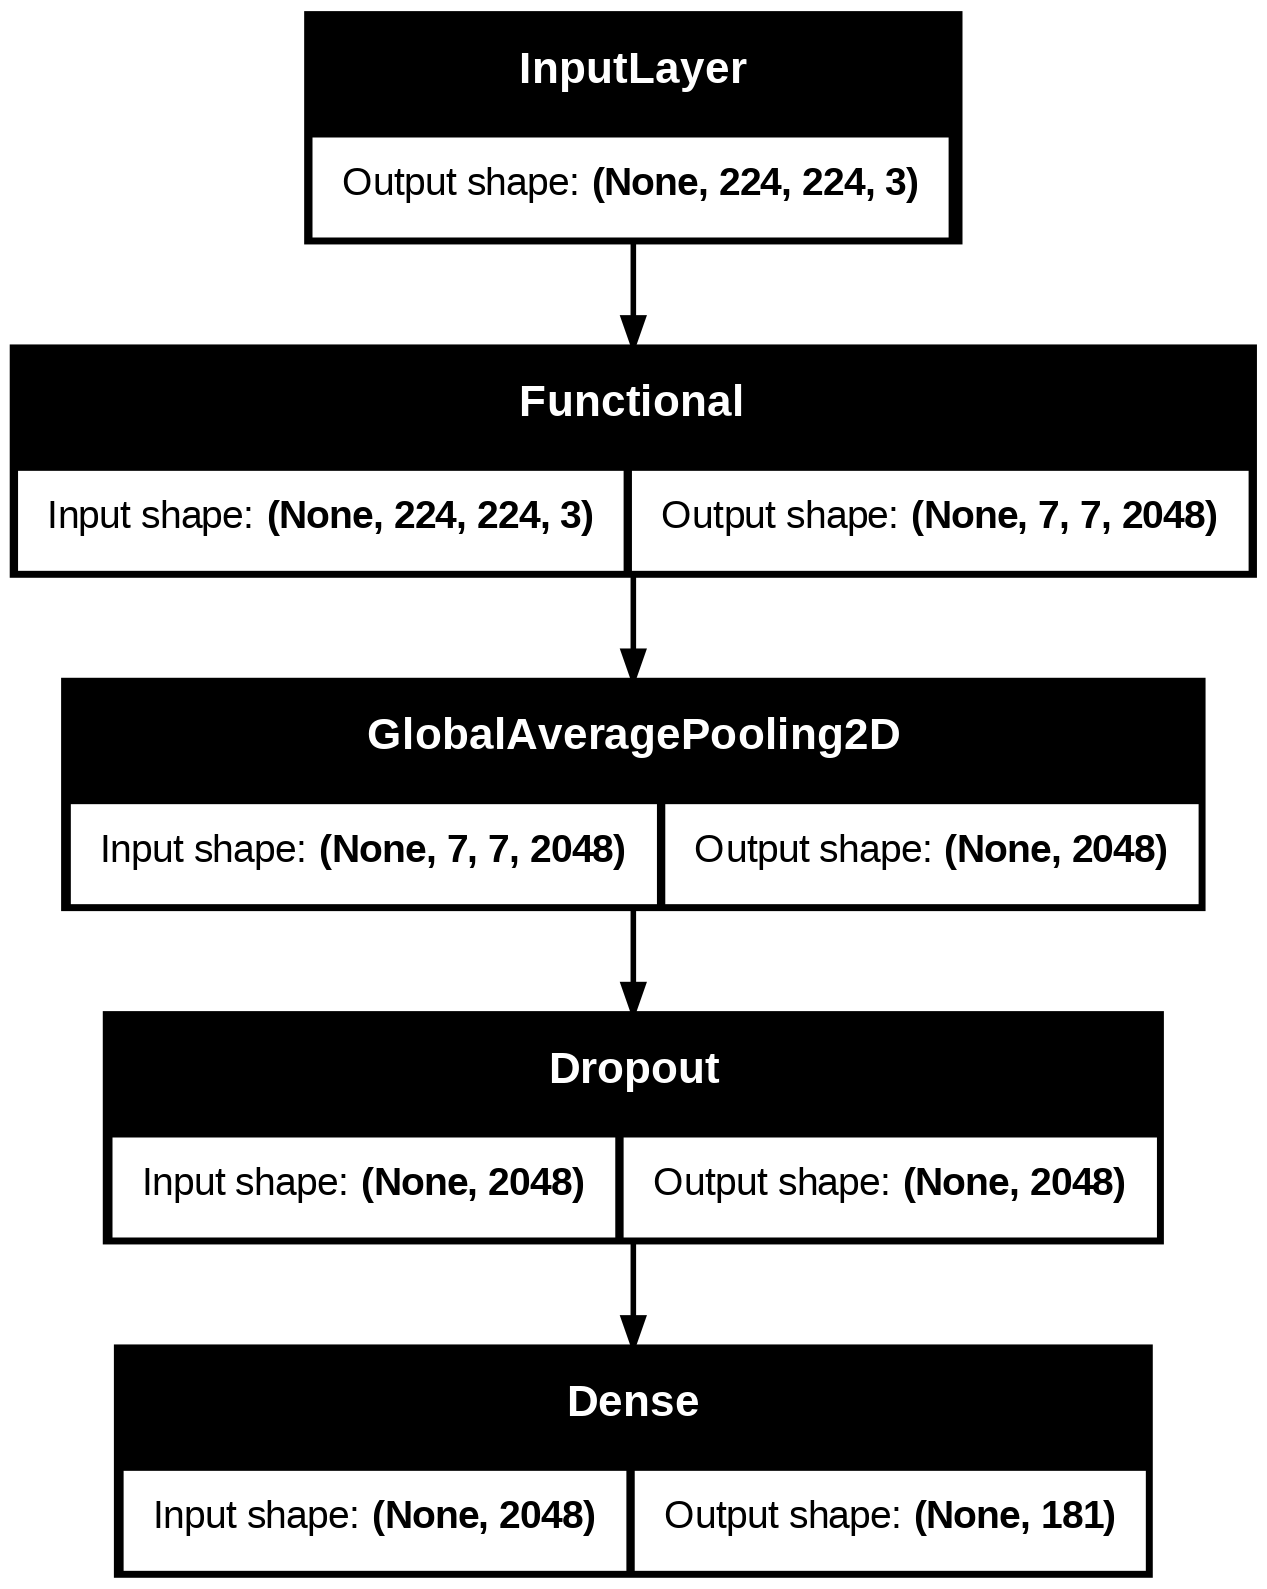

In [20]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs=10,
)

Epoch 1/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 231s 121ms/step - accuracy: 0.1883 - loss: 4.1488 - val_accuracy: 0.4340 - val_loss: 2.4340
Epoch 2/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 183s 101ms/step - accuracy: 0.4107 - loss: 2.5649 - val_accuracy: 0.4852 - val_loss: 2.2460
Epoch 3/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 183s 101ms/step - accuracy: 0.4573 - loss: 2.3589 - val_accuracy: 0.5006 - val_loss: 2.1640
Epoch 4/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 182s 101ms/step - accuracy: 0.4770 - loss: 2.2701 - val_accuracy: 0.5147 - val_loss: 2.1744
Epoch 5/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 182s 101ms/step - accuracy: 0.4920 - loss: 2.2092 - val_accuracy: 0.5169 - val_loss: 2.2111
Epoch 6/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 183s 101ms/step - accuracy: 0.5098 - loss: 2.1545 - val_accuracy: 0.5247 - val_loss: 2.2248
Epoch 7/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 183s 101ms/step - accuracy: 0.5166 - loss: 2.1509 - val_accuracy: 0.5245 - val_loss: 2.2272
Epoch 8/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 182s 101ms/step - ac

In [23]:
loss, accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - accuracy: 0.5450 - loss: 2.2188
Test Accuracy: 0.54


In [24]:
base_model.trainable = True

In [25]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [26]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [27]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [28]:
early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 7,
    restore_best_weights= True,
    start_from_epoch= 10,)

In [30]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("resnet50_best_model.keras", save_best_only=True, monitor="val_accuracy")

In [31]:
model.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history_finetune = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs= 30,
    callbacks= [early_stop, checkpoint]
    )

Epoch 1/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 356s 181ms/step - accuracy: 0.3544 - loss: 2.9781 - val_accuracy: 0.5878 - val_loss: 1.6163
Epoch 2/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 311s 172ms/step - accuracy: 0.6303 - loss: 1.4079 - val_accuracy: 0.6569 - val_loss: 1.3198
Epoch 3/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 310s 172ms/step - accuracy: 0.7663 - loss: 0.8615 - val_accuracy: 0.6799 - val_loss: 1.2757
Epoch 4/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 311s 172ms/step - accuracy: 0.8609 - loss: 0.4924 - val_accuracy: 0.7007 - val_loss: 1.2512
Epoch 5/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 310s 172ms/step - accuracy: 0.9301 - loss: 0.2519 - val_accuracy: 0.7155 - val_loss: 1.2169
Epoch 6/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 309s 171ms/step - accuracy: 0.9597 - loss: 0.1443 - val_accuracy: 0.7146 - val_loss: 1.2811
Epoch 7/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 311s 172ms/step - accuracy: 0.9764 - loss: 0.0881 - val_accuracy: 0.7233 - val_loss: 1.3230
Epoch 8/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 310s 171ms/step - ac

In [34]:
test_loss, test_accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {test_accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - accuracy: 0.7420 - loss: 1.3978
Test Accuracy: 0.74


In [44]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(50, 50))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [40]:
y_true = []
y_pred = []

for images, labels in test_dir:  
    predictions = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

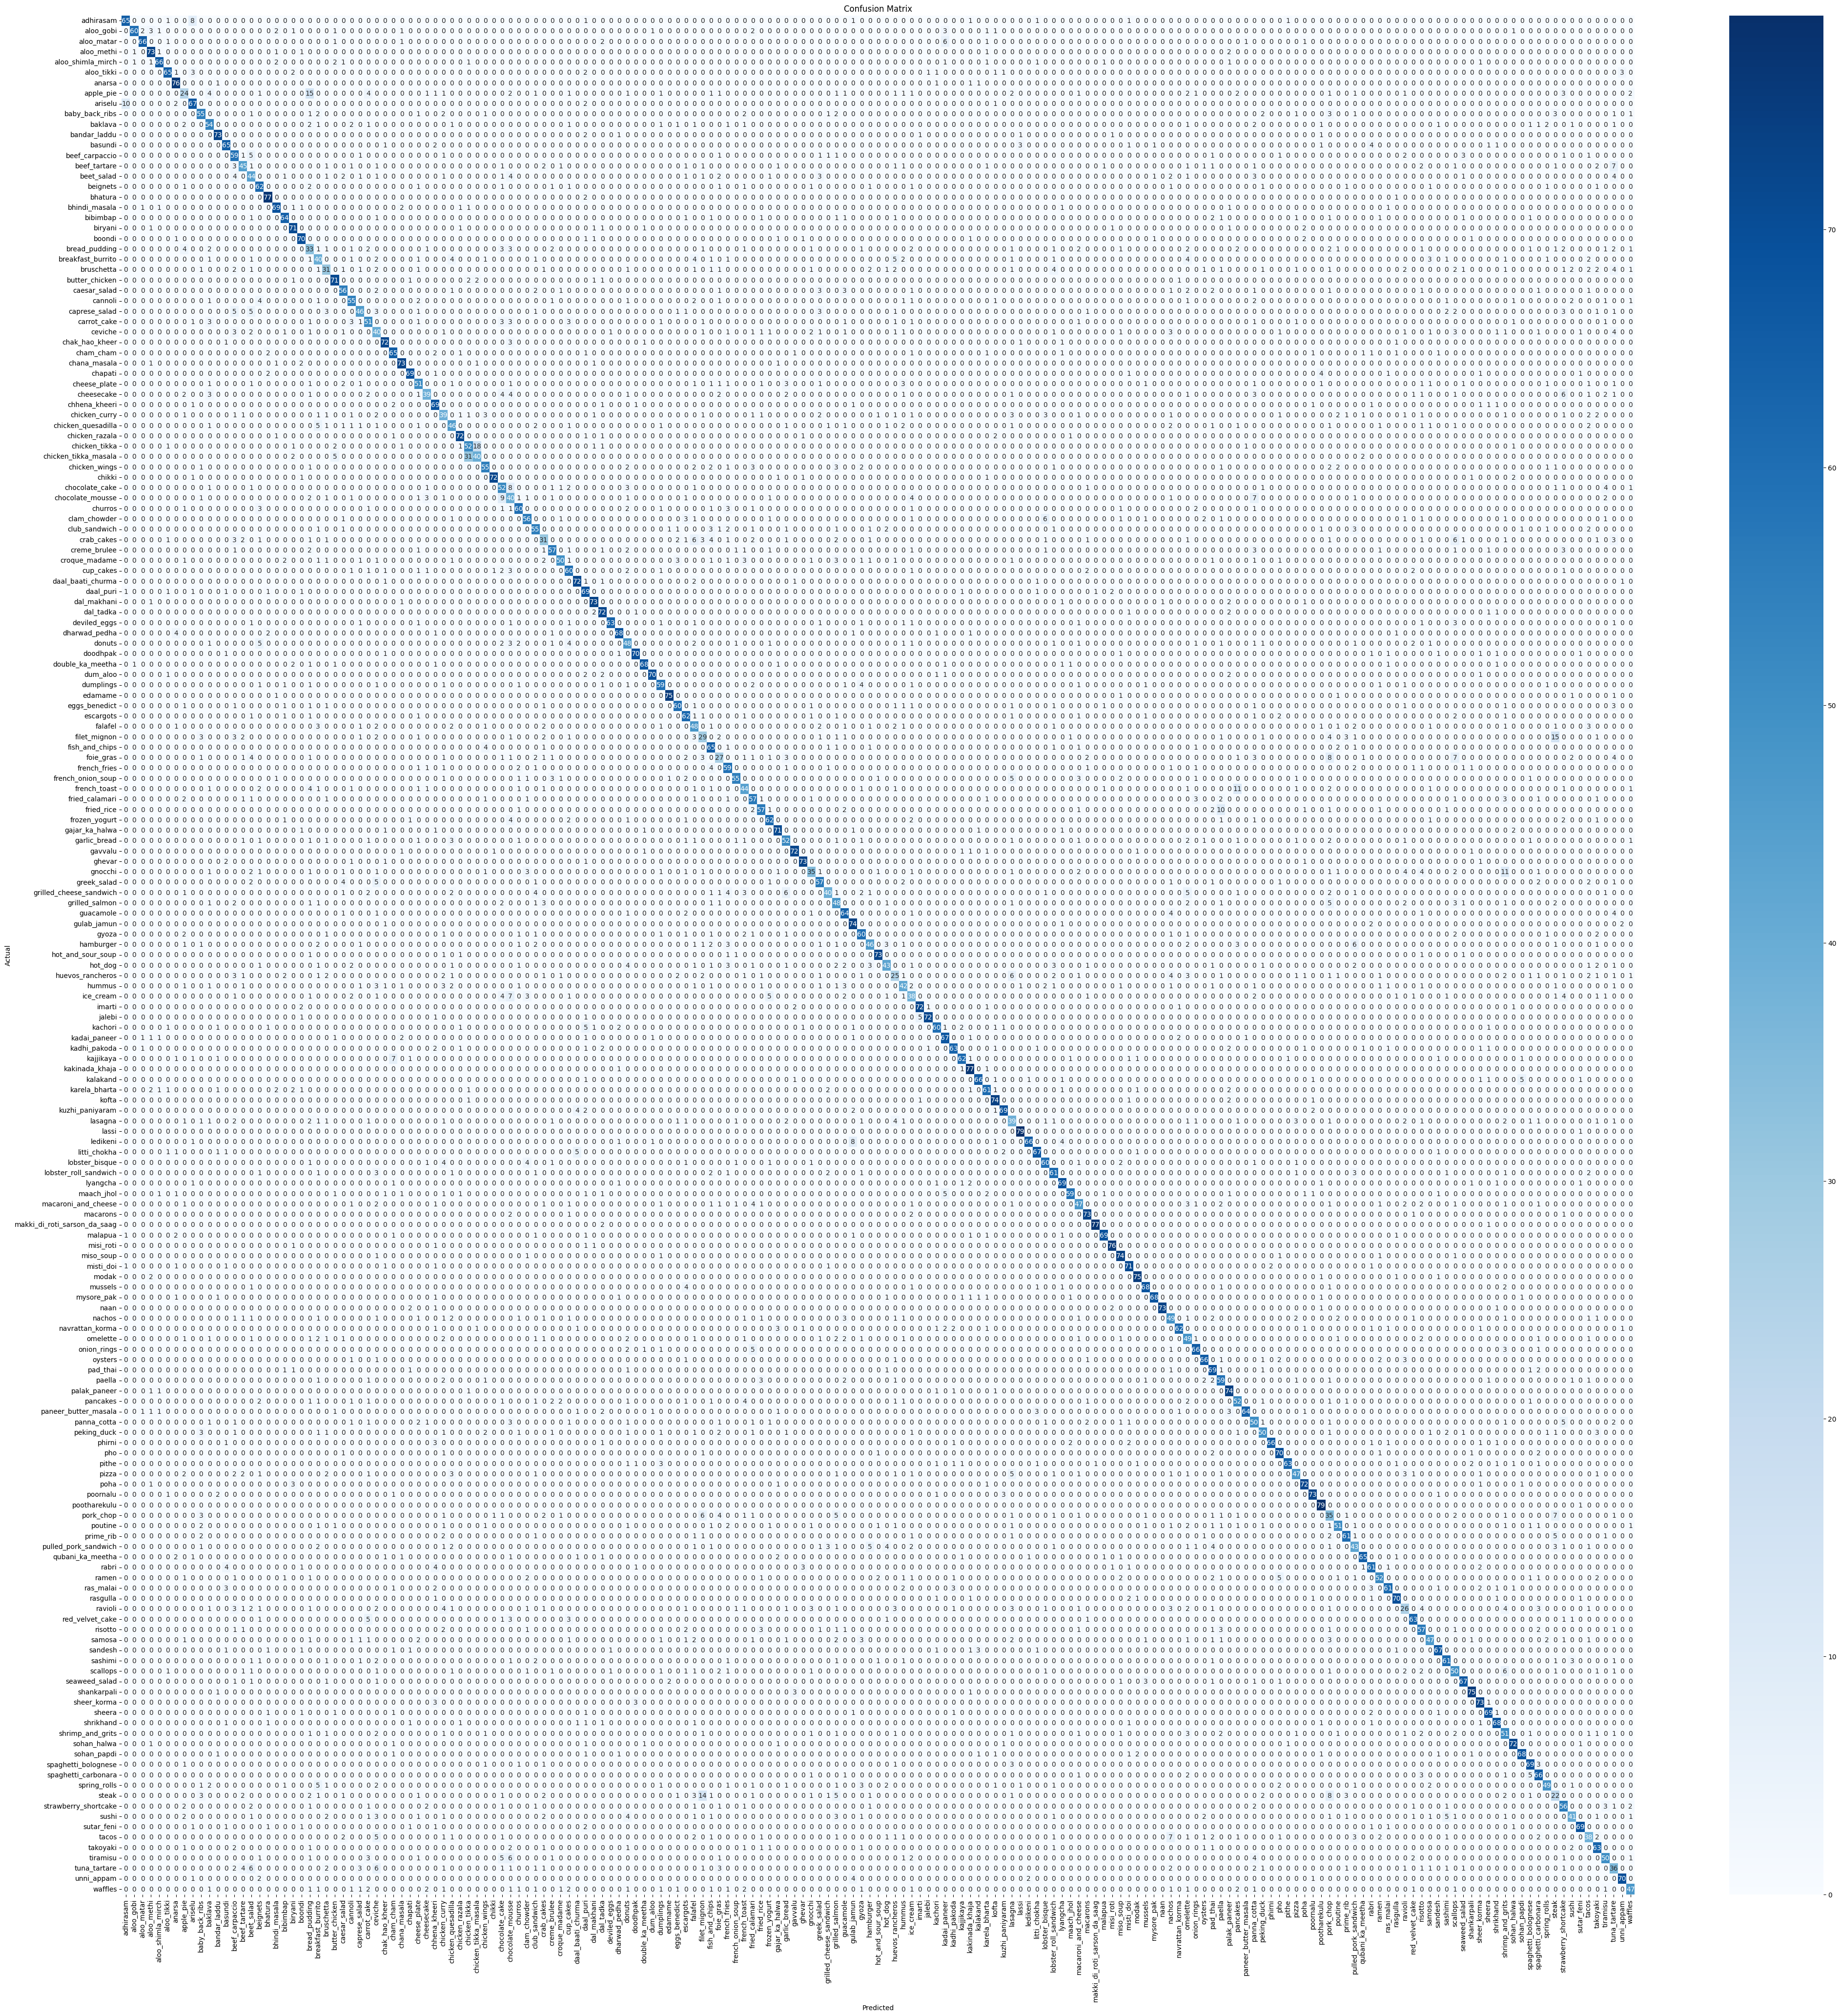

In [45]:
plot_confusion_matrix(y_true, y_pred, class_names)

In [46]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                              precision    recall  f1-score   support

                   adhirasam       0.83      0.81      0.82        80
                   aloo_gobi       0.95      0.75      0.84        80
                  aloo_matar       0.92      0.82      0.87        80
                  aloo_methi       0.82      0.91      0.86        80
           aloo_shimla_mirch       0.89      0.82      0.86        80
                  aloo_tikki       0.86      0.81      0.83        80
                      anarsa       0.81      0.95      0.87        80
                   apple_pie       0.42      0.30      0.35        80
                     ariselu       0.76      0.82      0.79        82
              baby_back_ribs       0.70      0.69      0.69        80
                     baklava       0.65      0.68      0.66        80
                bandar_laddu       0.88      0.91      0.90        80
                     basundi       0.78      0.81      0.80       